FIRST 5 ROWS OF DATASET
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

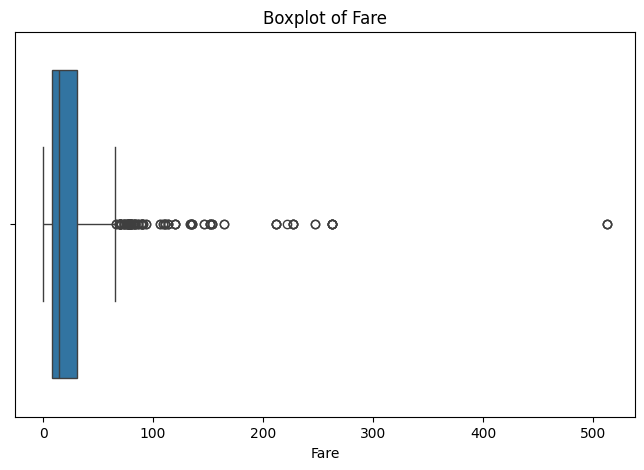


OUTLIERS REMOVED


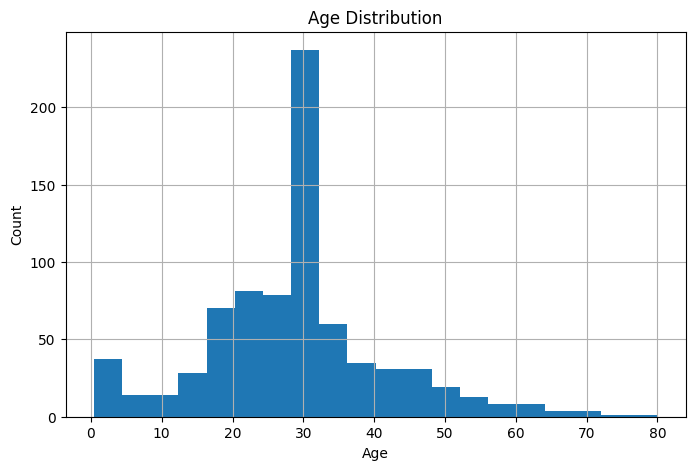

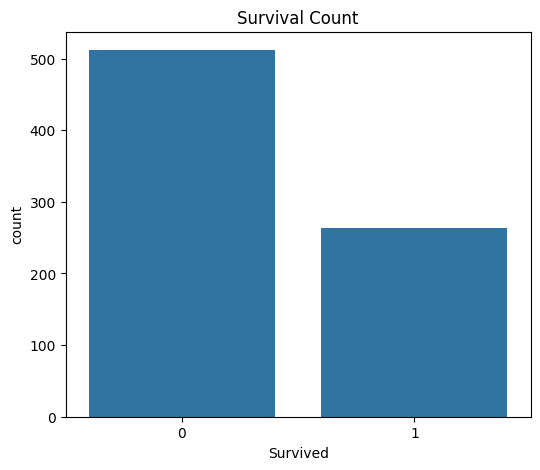

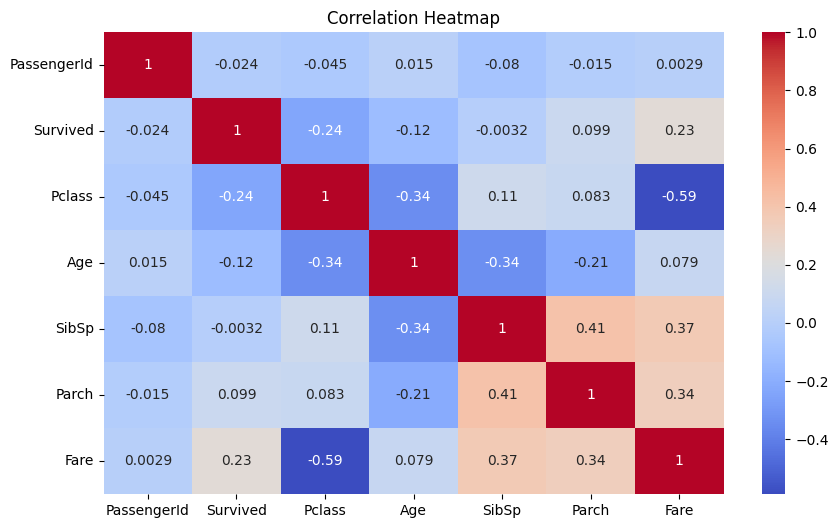

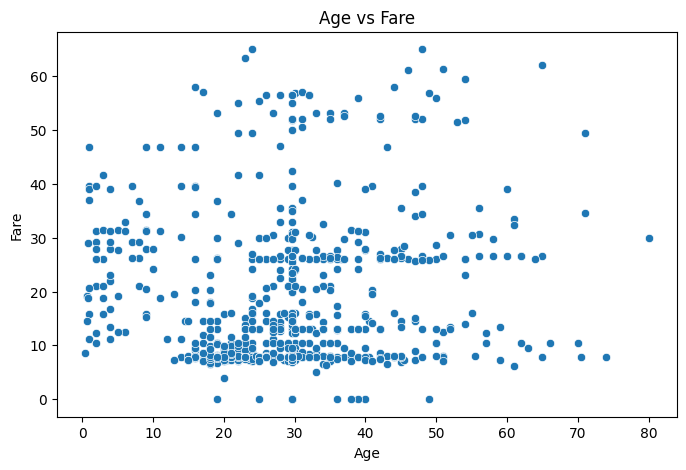

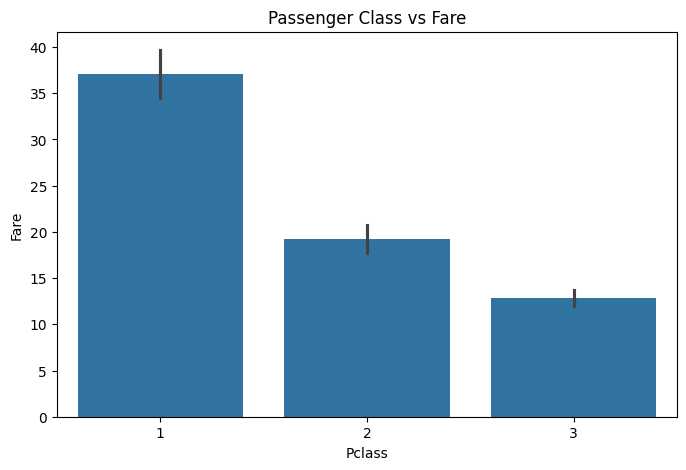


CLEANED DATASET SAVED SUCCESSFULLY

PROJECT INSIGHTS
1. Missing values were successfully handled.
2. Duplicate rows were removed.
3. Outliers in Fare column were removed.
4. Most passengers were aged between 20 and 40.
5. Higher-class passengers paid higher fares.
6. Correlation heatmap shows relationships between features.


In [ ]:
# ==========================================
# DATA CLEANING & VISUALIZATION PROJECT
# Titanic Dataset Analysis
# ==========================================

# STEP 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 2 — Load Dataset
# ==========================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# Display first 5 rows
print("FIRST 5 ROWS OF DATASET")
print(df.head())

# ==========================================
# STEP 3 — Dataset Information
# ==========================================

print("\nDATASET INFORMATION")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# ==========================================
# STEP 4 — Check Missing Values
# ==========================================

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# STEP 5 — Handle Missing Values
# ==========================================

# Fill missing Age values with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column due to too many missing values
df.drop('Cabin', axis=1, inplace=True)

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# ==========================================
# STEP 6 — Check and Remove Duplicates
# ==========================================

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nDUPLICATES REMOVED")

# ==========================================
# STEP 7 — Detect Outliers Using Boxplot
# ==========================================

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

# ==========================================
# STEP 8 — Remove Outliers Using IQR Method
# ==========================================

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower_limit) & (df['Fare'] <= upper_limit)]

print("\nOUTLIERS REMOVED")

# ==========================================
# STEP 9 — Data Visualization
# ==========================================

# -------------------------------
# 1. Histogram
# -------------------------------

plt.figure(figsize=(8,5))
df['Age'].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# -------------------------------
# 2. Survival Count Plot
# -------------------------------

plt.figure(figsize=(6,5))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# -------------------------------
# 3. Correlation Heatmap
# -------------------------------

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 4. Scatter Plot
# -------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Fare',
    data=df
)

plt.title("Age vs Fare")
plt.show()

# -------------------------------
# 5. Bar Plot
# -------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x='Pclass',
    y='Fare',
    data=df
)

plt.title("Passenger Class vs Fare")
plt.show()

# ==========================================
# STEP 10 — Save Cleaned Dataset
# ==========================================

df.to_csv("cleaned_titanic.csv", index=False)

print("\nCLEANED DATASET SAVED SUCCESSFULLY")

# ==========================================
# STEP 11 — Insights
# ==========================================

print("\nPROJECT INSIGHTS")

print("1. Missing values were successfully handled.")
print("2. Duplicate rows were removed.")
print("3. Outliers in Fare column were removed.")
print("4. Most passengers were aged between 20 and 40.")
print("5. Higher-class passengers paid higher fares.")
print("6. Correlation heatmap shows relationships between features.")

# ==========================================
# END OF PROJECT
# ==========================================